URL index: [Home](https://zzz.bwh.harvard.edu/luna-walkthrough/) | [Data](https://zzz.bwh.harvard.edu/luna-walkthrough/data/) | [S1. File QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p1/) | [S2. Signal QC](https://zzz.bwh.harvard.edu/luna-walkthrough/p2) | [S3. Staging](https://zzz.bwh.harvard.edu/luna-walkthrough/p3) | [S4. Artifacts](https://zzz.bwh.harvard.edu/luna-walkthrough/p4) | [S5. Analysis](https://zzz.bwh.harvard.edu/luna-walkthrough/p5)

Notebook index: [Index](../00_index.ipynb) | [S1. File QC](../p1/00_index.ipynb) | [S2. Signal QC](../p2/00_index.ipynb) | [S3. Staging](../p3/00_index.ipynb) | [S4. Artifacts](../p4/00_index.ipynb) | [S5. Analysis](../p5/00_index.ipynb)

---

#  3.3. Evaluating staging/signal quality (SOAP)
Walkthrough URL = [https://zzz.bwh.harvard.edu/luna-walkthrough/p3/soap/](https://zzz.bwh.harvard.edu/luna-walkthrough/p3/soap/)

As described here, Luna's `SOAP` command can quickly evaluate whether there are gross misalignments or other inconsistencies between staging and signal (typically, but to necessarily EEG) data.

In brief, `SOAP` tries to predict existing staging given one or more (EEG) signal. If the prediction within a single individual is poor (a low kappa), this suggests that the signal(s) and/or staging annotations are problematic (i.e. assuming the signals are normally expected to covary with true sleep stage).

Internally, `SOAP` performs a spectral analysis (Welch PSD) per epoch, then applies dimension reduction (PCA) over the epochs. It selects the components that are associated with stage labels. It then fits a linear discriminant analysis (LDA) model to predict stage given the PCs (just for that one individual), and compares the fitted to the observed values to obtain measures of accuracy (e.g. kappas, etc).

Note that this is a qualitatively different exercise than automated staging (which we address in the next segment). Here we are using a "prediction-like" approach only to assess the general association between existing staging and signals. As such, the kappa should not be interpreted in the same manner as is typically done for automated staging (true prediction).

In [1]:
import lunapi as lp
proj = lp.proj()
proj.sample_list( '../harm1.lst' )

initiated lunapi v1.2.3 <lunapi.lunapi0.luna object at 0x125f8a470> 

read 20 individuals from ../harm1.lst


## Evaluating stage consistency    

Here we'll run `SOAP` for a single channel (C3):

In [12]:
# luna harm1.lst -o out.db -s ' SOAP sig=C3 '
res = proj.silent_proc( 'SOAP sig=C3' ) 

In [13]:
# destrat out.db +SOAP -r CH -v NSS K K3 ACC ACC3 -p 2 
tbl = proj.table( 'SOAP' , 'CH' )[[ 'ID', 'NSS', 'K', 'K3' ]] 
tbl

,ID,NSS,K,K3
0,F01,5,0.804724,0.84059
1,F02,5,0.424689,0.436976
2,F03,5,0.261267,0.401939
3,F04,5,0.155276,0.174466
4,F05,5,0.794727,0.834719
5,F06,5,0.767253,0.824471
6,F07,5,0.822864,0.869462
7,F08,5,0.704074,0.760552
8,F09,5,0.831231,0.869116
9,F10,5,0.745036,0.79261


See the [original page](https://zzz.bwh.harvard.edu/luna-walkthrough/p3/soap/) for commentary on the results above.  To handle the issue with `M05` we can force `SOAP` to use all components:

In [6]:
# luna harm1.lst id=M05  -o out.db -s ' SOAP sig=C3 pc=0.9 '
p = proj.inst( 'M05' )
p.eval( 'SOAP sig=C3 pc=0.9' )

___________________________________________________________________
Processing: M05 | ../work/harm1/M05.edf
 duration 07.46.45, 28005s | time 22.00.00 - 05.46.45 | date 01.01.85

 signals: 57 (of 57) selected in a standard EDF file
  Fp1 | Fp2 | AF3 | AF4 | F7 | F5 | F3 | F1
  F2 | F4 | F6 | F8 | FT7 | FC5 | FC3 | FC1
  FC2 | FC4 | FC6 | FT8 | T7 | C5 | C3 | C1
  C2 | C4 | C6 | T8 | TP7 | CP5 | CP3 | CP1
  CP2 | CP4 | CP6 | TP8 | P7 | P5 | P3 | P1
  P2 | P4 | P6 | P8 | PO3 | PO4 | O1 | O2
  AFZ | FZ | FCZ | CZ | CPZ | PZ | POz | OZ
  FPZ
 ..................................................................
 CMD #1: SOAP
   options: pc=0.9 sig=C3
  using LDA for primary predictions
  ------------------------------------------------------------
  fitting SOAP model for single channel C3
  read 1 feature specifications (99 total features on 1 channels) from _1
  set epochs to default 30 seconds, 933 epochs
  set 0 leading/trailing sleep epochs to '?' (given end-wake=120 and end-sleep=5)
  a

,Command,Strata
0,SOAP,CH
1,SOAP,CH_ETYPE_SS
2,SOAP,CH_NSS_OBS_PRED
3,SOAP,CH_SS
4,SOAP,CH_VAR


Here we see the kappa is ~0 suggesting there is no above-chance correspondence between the staging and signal data.

In [9]:
p.table( 'SOAP' , 'CH' )[[ 'ACC' , 'ACC3' , 'K' , 'K3' ]] 

,ACC,ACC3,K,K3
0,0.635584,0.814577,0.0,0.0


Plotting the kappa for all individuals (and setting `M05` to 0):

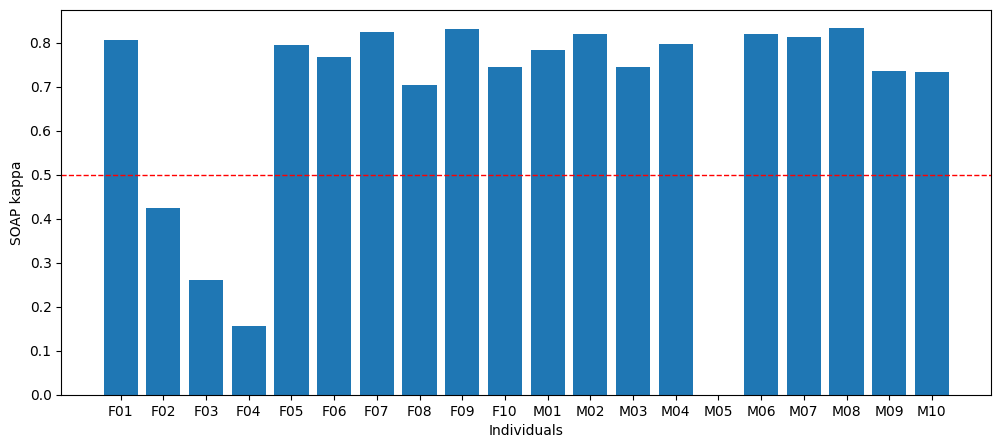

In [21]:
tbl = tbl.fillna(0)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))  
plt.bar( tbl.ID, tbl.K )
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
plt.xlabel('Individuals')
plt.ylabel('SOAP kappa')
plt.show() 

See the [original page](https://zzz.bwh.harvard.edu/luna-walkthrough/p3/soap/#evaluating-stage-consistency) for a discussion of the interpretation of these values.

## Epoch-level reviw

If we add the epoch flag to `SOAP`, it outputs epoch-level information: the observed stage label (`PRIOR`) plus the posterior probabilities (`PP_N1`, `PP_N2`, etc) and predicted stage (`PRED`). This is turned off by default as the outputs can get large for very large datasets. We'll also add `pc=0.9` so that `SOAP` emits values for `M05`:

In [25]:
# luna harm1.lst -o out.db -s ' SOAP sig=C3 epoch pc=0.9 '
res = proj.silent_proc( 'SOAP sig=C3 epoch pc=0.9' )

In [24]:
# destrat out.db +SOAP -r E CH > o.1
tbl = proj.table( 'SOAP' , 'CH_E' ) 
tbl

,ID,CH,E,DISC,DISC3,INC,PP_N1,PP_N2,PP_N3,PP_NR,PP_R,PP_W,PRED,PRIOR
0,F01,C3,1,1,1,1,0.050771,0.179983,0.750057,0.98081,0.003716,0.015474,N3,W
1,F02,C3,1,None,None,0,None,None,None,None,None,None,None,?
2,F03,C3,1,0,0,1,0.083975,0.044141,0.034505,0.162621,0.011735,0.825643,W,W
3,F04,C3,1,1,1,1,0.036075,0.573679,0.128931,0.738684,0.074819,0.186496,N2,W
4,F05,C3,1,0,0,1,0.000008,0.0,0.0,0.000008,0.000016,0.999976,W,W
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17989,M07,C3,994,0,0,1,0.000029,0.999885,0.000086,1.0,0.0,0.0,N2,N2
17990,M07,C3,995,0,0,1,0.000125,0.998337,0.001537,1.0,0.0,0.0,N2,N2
17991,M07,C3,996,0,0,1,0.000036,0.999436,0.000528,1.0,0.0,0.0,N2,N2
17992,M07,C3,997,0,0,1,0.000048,0.999063,0.000889,1.0,0.0,0.0,N2,N2


First looking at a "clean" record with a high kappa, e.g. `M06`:

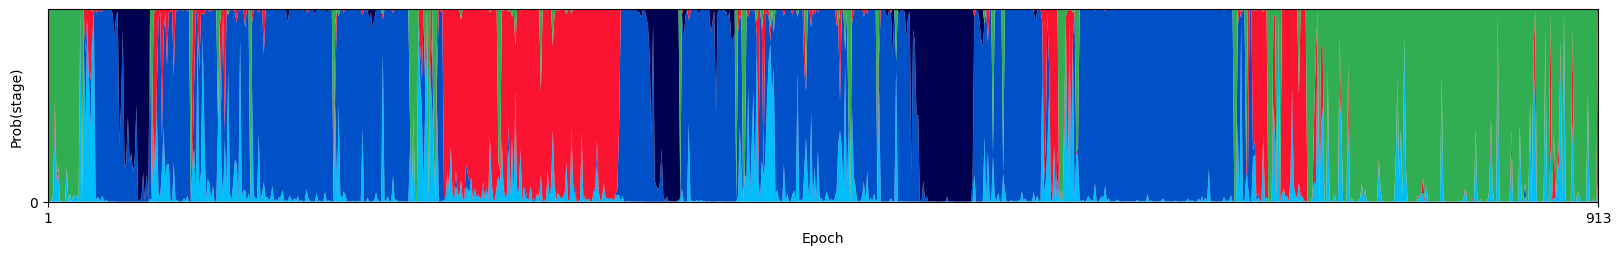

In [26]:
lp.hypno_density( tbl[ tbl.ID == 'M06' ] ) 

In contrast, let's look at the four cases were we had very low kappas:

First, here is `M05`, for which the stage labels were completely scrambled in our manipulation:

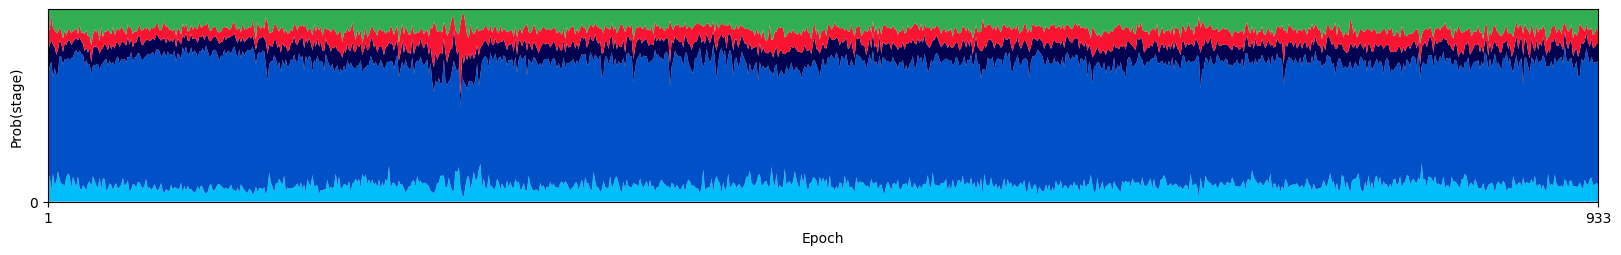

In [29]:
lp.hypno_density( tbl[ tbl.ID == 'M05' ] ) 

Next, we'll look at `F03` and `F04` - these were both "valid" hypnograms (versus being completely scrambled), but were incorrectly assigned to the wrong individuals:

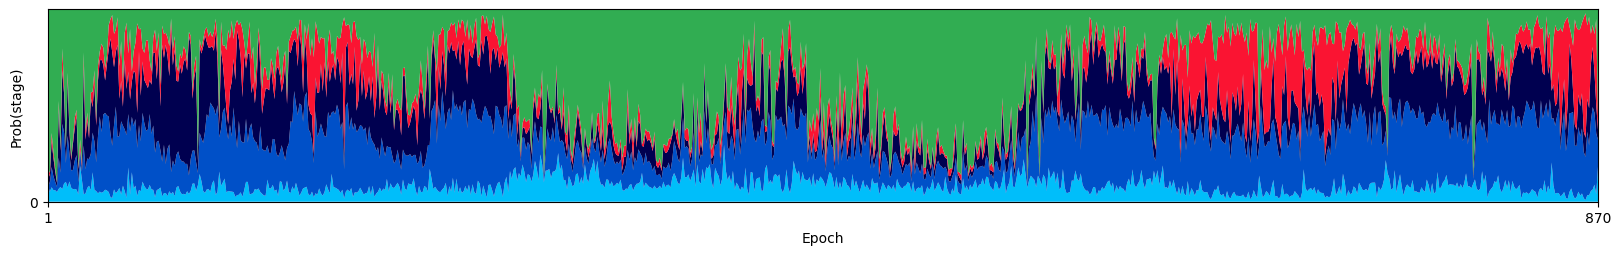

In [30]:
lp.hypno_density( tbl[ tbl.ID == 'F03' ] ) 

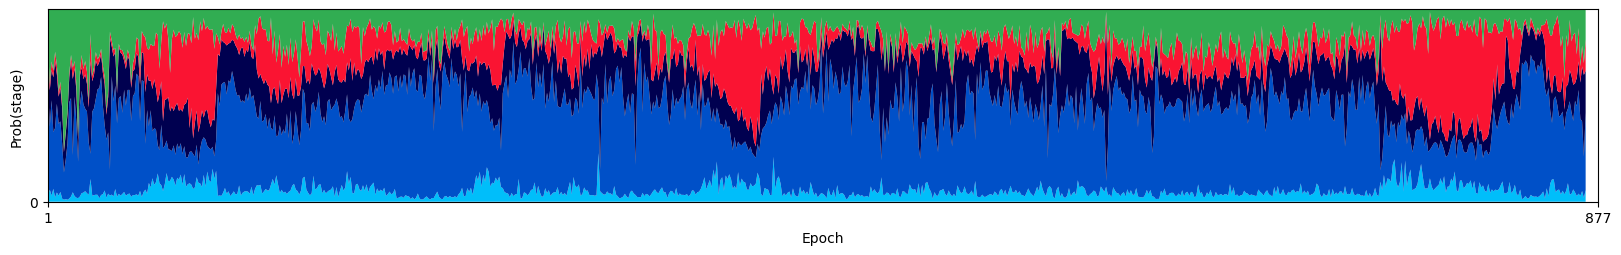

In [31]:
lp.hypno_density( tbl[ tbl.ID == 'F04' ] ) 

Finally, let's look at a more subtle case: for `F02`, we simply shifted the stage labels by about 10 minutes:

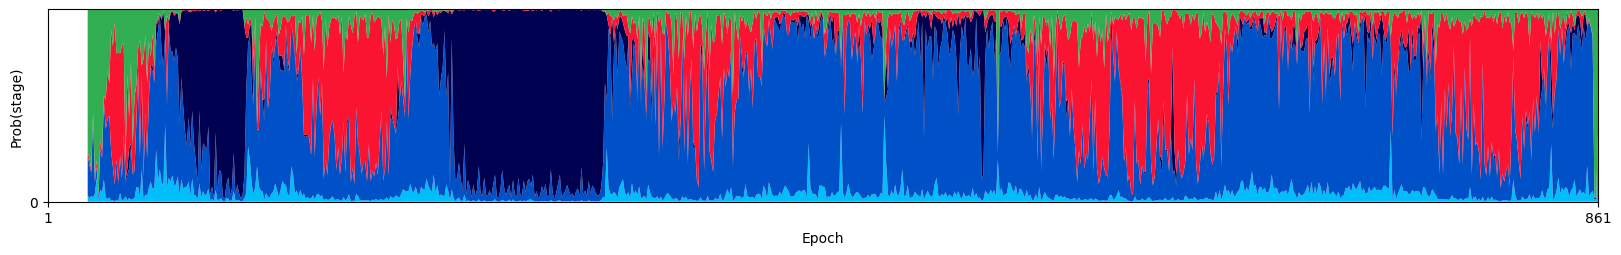

In [32]:
lp.hypno_density( tbl[ tbl.ID == 'F02' ] ) 

Looking at the original and then the SOAP-derived hypnograms, we can see evidence for this type of "shifting":

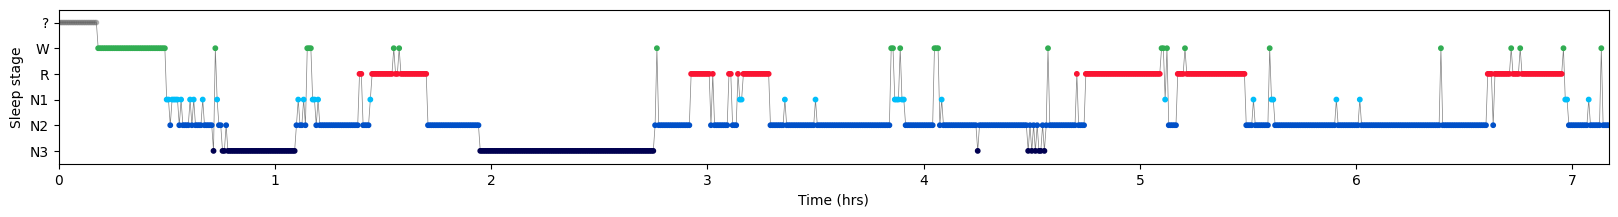

In [34]:
lp.hypno( tbl[ tbl.ID == 'F02' ][ 'PRIOR' ] ) 

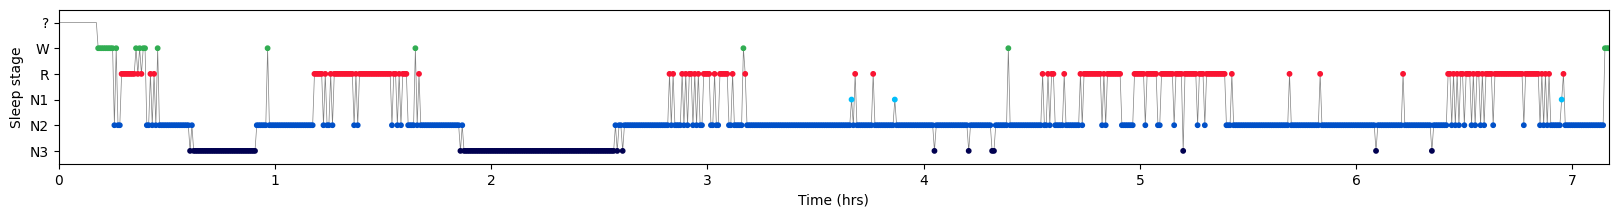

In [35]:
lp.hypno( tbl[ tbl.ID == 'F02' ][ 'PRED' ] ) 

## Multi-channel SOAP

Here we'll re-run `SOAP` on all channels. __Note, it may take five minutes or so__ to evaluate all 1,140 (20 * 57) channels -- you can skip this step without impacting the rest of the walkthrough and just look at the results below, if you wish. We'll omit the epoch-level output.

In [36]:
# luna harm1.lst -o out.db -s ' SOAP sig=${eeg} pc=0.9 '
res = proj.silent_proc( 'SOAP sig=${eeg} pc=0.9' ) 

In [37]:
# destrat out.db +SOAP -r CH -v NSS K K3 > o.1
tbl = proj.table( 'SOAP' , 'CH' )[[ 'ID', 'CH', 'NSS', 'K', 'K3' ]] 

We can check each individual has 57 outputs (one per channel):

In [41]:
tbl.NSS.value_counts()

NSS
5    1139
Name: count, dtype: int64

Here we plot the 5-class kappa for all channels/individuals (colors indicate the individual):

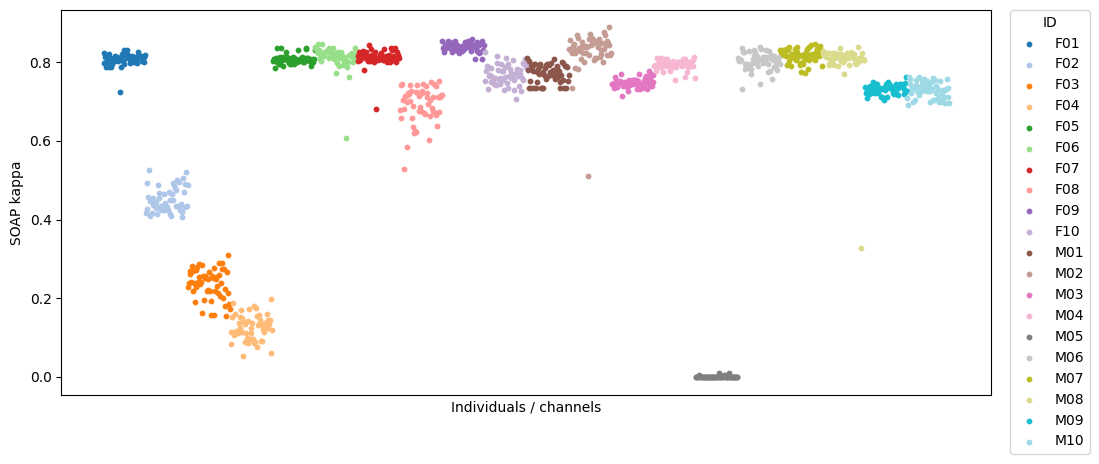

In [48]:
import numpy as np

tbl = tbl.sort_values( 'ID' )

unique_ids = tbl.ID.unique()
colors = plt.cm.tab20(range(len(unique_ids)))  # Choose a color palette
color_map = dict(zip(unique_ids, colors))
tbl['X'] = np.linspace(0, 1, len(tbl.K) )

plt.figure(figsize=(12, 5))  # (width, height) in inches
for uid in unique_ids:
    subset = tbl[tbl['ID'] == uid]
    plt.scatter( subset.X , subset.K,  label=uid, color=color_map[uid], s=10)

# Add legend and labels
plt.xlabel('Individuals / channels')
plt.ylabel('SOAP kappa' )
plt.legend(title='ID', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.xticks([]) 
plt.show()

## Aligning misaligned staging

There is nothing we can do for the scrambled case, `M05`: as is evident by simply looking at the hypnogram, it needs replacing (or using automated staging, etc). But can we do anything to potentially salvage the manual staging for the other three recordings?

First we'll consider `F02`. If we have a low `SOAP` kappa but the predictions look "shifted" - or, more likely, if we know that the timing information has been lost on the staging (e.g. it has nonsensical time-stamps starting in the mid-morning, when the EDF starts in the evening, etc), then we can turn to Luna's `PLACE` as described in this vignette.

`PLACE` requires a simple `.eannot`-style text file of the stage labels: these stages will be aligned to the epochs in the EDF. We can use the `STAGE` command (which is just a minimal version of `HYPNO epoch`) to output these stage labels:

In [53]:
p = proj.inst( 'F02' )
p.eval( 'STAGE eannot=../tmp/F02.stages' ) 

___________________________________________________________________
Processing: F02 | ../work/harm1/F02.edf
 duration 07.10.33, 25833s | time 22.00.00 - 05.10.33 | date 01.01.85

 signals: 57 (of 57) selected in a standard EDF file
  Fp1 | Fp2 | AF3 | AF4 | F7 | F5 | F3 | F1
  F2 | F4 | F6 | F8 | FT7 | FC5 | FC3 | FC1
  FC2 | FC4 | FC6 | FT8 | T7 | C5 | C3 | C1
  C2 | C4 | C6 | T8 | TP7 | CP5 | CP3 | CP1
  CP2 | CP4 | CP6 | TP8 | P7 | P5 | P3 | P1
  P2 | P4 | P6 | P8 | PO3 | PO4 | O1 | O2
  AFZ | FZ | FCZ | CZ | CPZ | PZ | POz | OZ
  FPZ
 ..................................................................
 CMD #1: STAGE
   options: eannot=../tmp/F02.stages sig=*
  set epochs to default 30 seconds, 861 epochs
  set 0 leading/trailing sleep epochs to '?' (given end-wake=120 and end-sleep=5)
  writing epoch-level sleep stages to ../tmp/F02.stages


We'll check the temporary file has been created, here printing the first ten rows (should be one stage per row, all _lights on_):

In [54]:
print(''.join(open('../tmp/F02.stages').readlines()[:10]))

L
L
L
L
L
L
L
L
L
L



To run `PLACE` on this:

In [55]:
# luna harm1.lst id=F02 -o out.db -s PLACE sig=C3 stages=stg.txt out=new.eannot
p.eval( 'PLACE sig=C3 stages=../tmp/F02.stages out=../tmp/F02.eannot' )

 ..................................................................
 CMD #1: PLACE
   options: out=../tmp/F02.eannot sig=C3 stages=../tmp/F02.stages
  using LDA for primary predictions
  read 861 epochs from ../tmp/F02.stages
  based on EDF, there are 861 30-s epochs
  requiring 0.1 proportion of EDF, and 0.5 of supplied stages overlap

  applying Welch with 4s segments (2s overlap), using median over segments
  expecting 99 features (for 861 epochs) and 1 channels
  standardizing X
  final feature matrix X: 99 features over 861 epochs
  of 861 total epochs, valid staging for 861, and of those 861 passed outlier removal
  outlier counts: flat, Hjorth, components, trimmed -> total : 0, 0, 0, 0 -> 0
  re-standardizing X after removing bad epochs

  optimal epoch offset = -22 epochs (kappa = 0.77312)
  which spans 839 epochs (of 861 in the EDF, and of 861 in the input stages)
  writing aligned stage file (.eannot) to ../tmp/F02.eannot


,Command,Strata
0,PLACE,BL
1,PLACE,OFFSET


We can extract the fit for all possible epochs:

In [56]:
# destrat out.db +PLACE -r OFFSET > o.1
tbl = p.table( 'PLACE' , 'OFFSET' ) 
tbl

,ID,OFFSET,FIT,K,K3,NE,NS,OLAP_EDF,OLAP_N,OLAP_STG,S,S3,SS
0,F02,-860.0,0,None,None,0,0,0.001161,1,0.001161,None,None,"?:860,N2:1"
1,F02,-859.0,0,None,None,0,0,0.002323,2,0.002323,None,None,"?:859,N2:2"
2,F02,-858.0,0,None,None,0,0,0.003484,3,0.003484,None,None,"?:858,N2:3"
3,F02,-857.0,0,None,None,0,0,0.004646,4,0.004646,None,None,"?:857,N2:4"
4,F02,-856.0,0,None,None,0,0,0.005807,5,0.005807,None,None,"?:856,N2:4,W:1"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716,F02,856.0,0,None,None,0,0,0.005807,5,0.005807,None,None,?:861
1717,F02,857.0,0,None,None,0,0,0.004646,4,0.004646,None,None,?:861
1718,F02,858.0,0,None,None,0,0,0.003484,3,0.003484,None,None,?:861
1719,F02,859.0,0,None,None,0,0,0.002323,2,0.002323,None,None,?:861


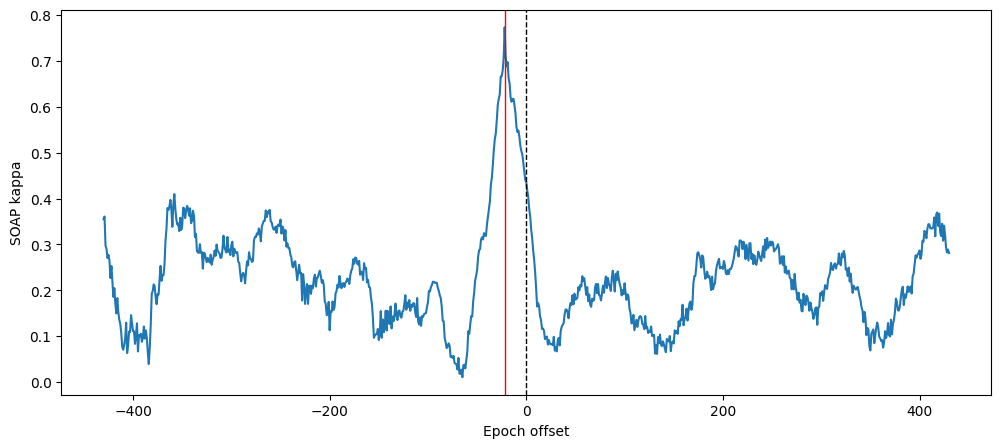

In [61]:
plt.figure(figsize=(12, 5))  
plt.plot( tbl.OFFSET, tbl.K )
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=-22, color='red', linestyle='-', linewidth=1)
plt.xlabel('Epoch offset')
plt.ylabel('SOAP kappa')
plt.show() 

In [66]:
# destrat out.db +PLACE -r OFFSET/-25,-24,-22,-21,-20 -v K K3 -p 2
tbl[ ( tbl.OFFSET >= -25 ) & ( tbl.OFFSET <= -20 ) ][ [ 'OFFSET', 'K', 'K3' ] ]

,OFFSET,K,K3
835,-25.0,0.666464,0.633658
836,-24.0,0.679076,0.65158
837,-23.0,0.706392,0.697019
838,-22.0,0.77312,0.79951
839,-21.0,0.710251,0.715303
840,-20.0,0.687799,0.677264


## Matching swapped annotations

What about the two remaining individuals, `F03` and `F04`? If we suspect that files have been swapped, we can in principle use `SOAP` to figure this out.

__Note:__ _This is definitely an (extreme) edge case usage of SOAP, that might not be practical in large samples. At a certain point, it would probably be cleaner to use automated staging to restage files, or even redo the manual staging. We nonetheless include this as an illustration of how SOAP works._

See [the original webpage](https://zzz.bwh.harvard.edu/luna-walkthrough/p3/soap/#matching-swapped-annotations) for more context on this.

Below, we re-run `SOAP` but forcing (for all individuals) the annotations from `F03` (and skipping their original annotations specified in the sample list (`skip-sl-annots`).  (Note: _it will be important to remember to turn off these settings afterwards_)

In [99]:
sl = proj.sample_list()
for i in range(1, 21):
    print( str(sl.loc[ i , 'EDF']) )

../work/harm1/F01.edf
../work/harm1/F02.edf
../work/harm1/F03.edf
../work/harm1/F04.edf
../work/harm1/F05.edf
../work/harm1/F06.edf
../work/harm1/F07.edf
../work/harm1/F08.edf
../work/harm1/F09.edf
../work/harm1/F10.edf
../work/harm1/M01.edf
../work/harm1/M02.edf
../work/harm1/M03.edf
../work/harm1/M04.edf
../work/harm1/M05.edf
../work/harm1/M06.edf
../work/harm1/M07.edf
../work/harm1/M08.edf
../work/harm1/M09.edf
../work/harm1/M10.edf


In [114]:
# luna harm1.lst skip-sl-annots=T annot-file=work/harm1/F03.annot -o out1.db -s SOAP sig=C3

# we'll use a Python loop to explicitly loop over individuals
# but always attach staging annotations from individual F03
# asking for the ID with _F03 append will create an empty instance
# rather than pull from the attached sample list

res = []

proj.silence()

for i in range(1, 21):
    id = str(sl.loc[ i , 'ID']) + "_F03"
    edf = str(sl.loc[ i , 'EDF']) 
    annots = '../work/harm1/F03.annot' 

    p = proj.inst( id )
    p.attach_edf( edf )
    p.attach_annot( annots )

    p.eval( 'SOAP sig=C3' )
    tbl = p.table( 'SOAP', 'CH' )
    res.append( float( tbl.K.iloc[0] ) )

proj.silence( False )

And plotting the results, we see that `F04` matches best:

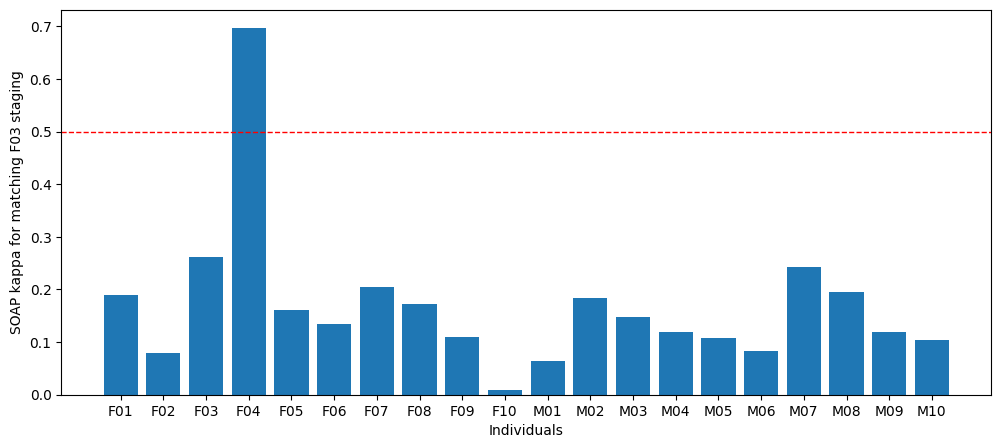

In [115]:
plt.figure(figsize=(12, 5))  
plt.bar( sl.ID, res )
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
plt.xlabel('Individuals')
plt.ylabel('SOAP kappa for matching F03 staging')
plt.show() 

Note: the following __did not work__ in `lunapi` (i.e. the single `annot-file` is _not_ applied across all individuals when using `proc()`.  This is a bug that will be fixed in lunapi.

      proj.var( 'skip-sl-annots' , 'T' )
      proj.var( 'annot-file' , '../work/harm1/F03.annot' )
      res = proj.silent_proc( 'SOAP sig=C3' )

Conversely: if we plug in `F04` staging values for all individuals, we'll see that `F04`'s staging best aligns with `F03`'s signal data, suggesting a file naming issue between these two individuals that needs to be resolved. 

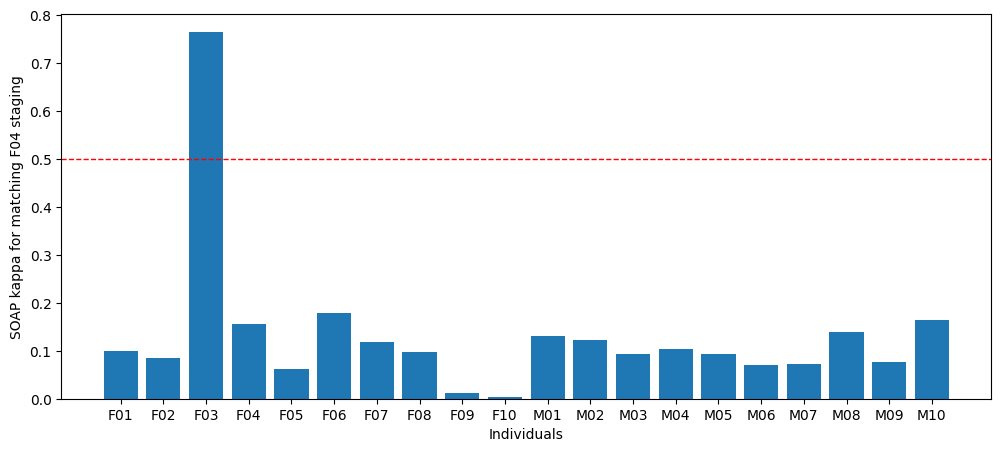

In [112]:
res = []

proj.silence()

for i in range(1, 21):
    id = str(sl.loc[ i , 'ID']) + "_F03"
    edf = str(sl.loc[ i , 'EDF']) 
    annots = '../work/harm1/F04.annot' 

    p = proj.inst( id )
    p.attach_edf( edf )
    p.attach_annot( annots )

    p.eval( 'SOAP sig=C3' )
    tbl = p.table( 'SOAP', 'CH' )
    res.append( float( tbl.K.iloc[0] ) )

proj.silence(False)

plt.figure(figsize=(12, 5))  
plt.bar( sl.ID, res )
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
plt.xlabel('Individuals')
plt.ylabel('SOAP kappa for matching F04 staging')
plt.show() 

---

Please read the [summary section](https://zzz.bwh.harvard.edu/luna-walkthrough/p3/soap/#summary) on the primary website.

Now we're ready to go to the [next section](04_pops.ipynb) to consider automated staging.